<a href="https://colab.research.google.com/github/2catch2/BalanceEfficiency1-3/blob/main/BalEff1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

====== GEOMETRIC STATE ENGINE TELEMETRY ======
Total Sim Steps Completed  : 2000
Steps spent in Contraction : 124
Steps spent in Expansion   : 1876
Final Balance Index (I)    : -766.5255 (Ideal target is 0)
Final Space Efficiency (η) : 2.46%


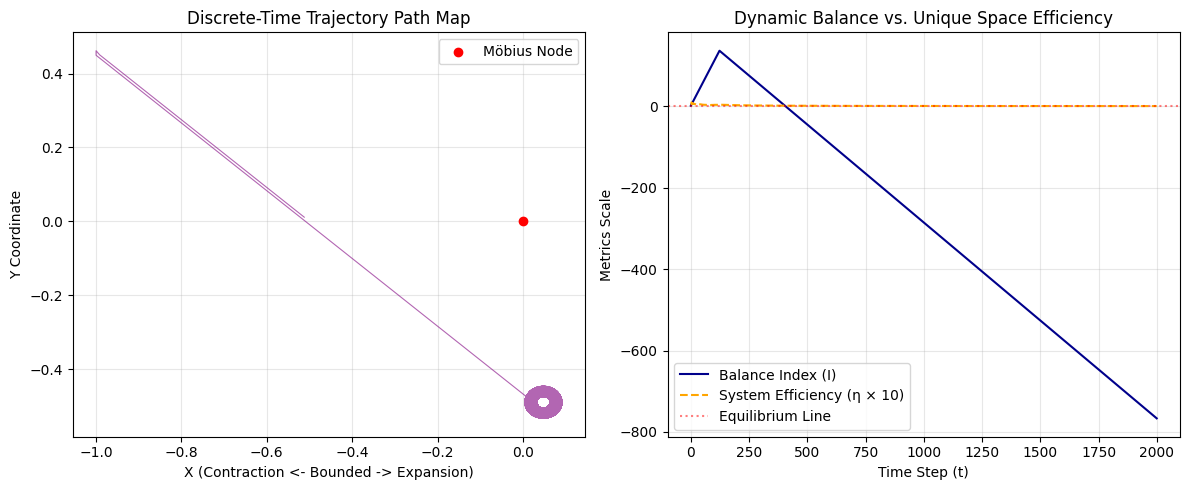

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def run_bowtie_state_engine(steps=2000):
    # --- System Constants ---
    phi = (1 + np.sqrt(5)) / 2          # Golden Ratio (~1.618033)
    golden_angle = np.radians(137.5)   # Injection/spacing angle
    drift_angle = np.radians(6.5)       # Möbius drift offset

    # --- State Variables Initialization ---
    x, y = -0.5, 0.0                     # Position vector (Starts in left rhombus)
    theta = golden_angle                 # Initial direction direction angle
    phase = 1.0 + 0j                    # Complex wave phase
    amplitude = 1.0                     # Amplitude / energy

    # --- Counters & Telemetry Logs ---
    N_c = 0                             # Steps spent contracting
    N_e = 0                             # Steps spent expanding

    trajectory = []                     # Stores path coordinates
    balance_history = []                # Stores structural balance index (I)
    efficiency_history = []             # Stores unique area path efficiency (eta)
    visited_regions = set()             # Tracks unique grid cells for entropy mapping
    grid_resolution = 50                # Grid scale to track regional unique coverage

    base_step_size = 0.05

    for t in range(1, steps + 1):
        # 1. Geometry Detection
        r = np.sqrt(x**2 + y**2)
        in_node = (r < 0.15)            # Core Möbius center region around (0,0)
        in_contraction = (x < 0 and not in_node)  # Left hand side rhombus
        in_expansion = (x >= 0 and not in_node)   # Right hand side rhombus

        # 2. State Machine Rule Processing
        if in_node:
            # Rule (e): Möbius phase inversion + direction flip + 6.5° drift
            phase = -phase              # Flip complex phase
            theta = theta + np.pi + drift_angle
            # Push packet out of node to avoid getting stuck in singularity loop
            x += base_step_size * np.cos(theta)
            y += base_step_size * np.sin(theta)

        elif in_contraction:
            # Rule (b): Contraction (1/3)
            N_c += 1
            step = base_step_size * (1.0 / 3.0)
            x += step * np.cos(theta)
            y += step * np.sin(theta)

        elif in_expansion:
            # Rule (d): Expansion (phi)
            N_e += 1
            step = base_step_size * phi
            x += step * np.cos(theta)
            y += step * np.sin(theta)
            # Apply golden angular spacing spacing shift
            theta += golden_angle

        # 3. Curvature (π boundary constraint)
        if x < -1.0 or x > 1.0 or y < -1.0 or y > 1.0:
            theta += np.pi / 2          # Bend trajectory inward
            x = np.clip(x, -1.0, 1.0)
            y = np.clip(y, -1.0, 1.0)

        # Keep heading angle localized within bounded radians
        theta = theta % (2 * np.pi)

        # 4. Live Calculation of Equations
        # Equation 1: Scale Balance Index (I) -> Target is 0
        I = (np.log(3) * N_c) - (np.log(phi) * N_e)

        # Equation 2: Unique Spatial Efficiency Tracker (eta)
        grid_x = int((x + 1.0) / 2.0 * grid_resolution)
        grid_y = int((y + 1.0) / 2.0 * grid_resolution)
        visited_regions.add((grid_x, grid_y))

        structural_loss_coefficient = 1.0 - (6.5 / 180.0) # ~0.9639
        spatial_coverage_rate = len(visited_regions) / t
        eta = structural_loss_coefficient * spatial_coverage_rate

        # Log telemetry data
        trajectory.append((x, y))
        balance_history.append(I)
        efficiency_history.append(eta)

    return np.array(trajectory), balance_history, efficiency_history, N_c, N_e

# --- Execute Simulation ---
steps_to_run = 2000
path, balance, efficiency, final_Nc, final_Ne = run_bowtie_state_engine(steps=steps_to_run)

# --- Output Report Performance ---
print("====== GEOMETRIC STATE ENGINE TELEMETRY ======")
print(f"Total Sim Steps Completed  : {steps_to_run}")
print(f"Steps spent in Contraction : {final_Nc}")
print(f"Steps spent in Expansion   : {final_Ne}")
print(f"Final Balance Index (I)    : {balance[-1]:.4f} (Ideal target is 0)")
print(f"Final Space Efficiency (η) : {efficiency[-1] * 100:.2f}%")
print("==============================================")

# --- Visualization Plots ---
plt.figure(figsize=(12, 5))

# Plot Trajectory (Bowtie geometry)
plt.subplot(1, 2, 1)
plt.plot(path[:, 0], path[:, 1], color='purple', alpha=0.6, linewidth=0.8)
plt.scatter(0, 0, color='red', zorder=5, label='Möbius Node')
plt.title("Discrete-Time Trajectory Path Map")
plt.xlabel("X (Contraction <- Bounded -> Expansion)")
plt.ylabel("Y Coordinate")
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Balance Matrix
plt.subplot(1, 2, 2)
plt.plot(balance, label='Balance Index (I)', color='darkblue')
plt.plot([e * 10 for e in efficiency], label='System Efficiency (η × 10)', color='orange', linestyle='--')
plt.axhline(0, color='red', alpha=0.5, linestyle=':', label='Equilibrium Line')
plt.title("Dynamic Balance vs. Unique Space Efficiency")
plt.xlabel("Time Step (t)")
plt.ylabel("Metrics Scale")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

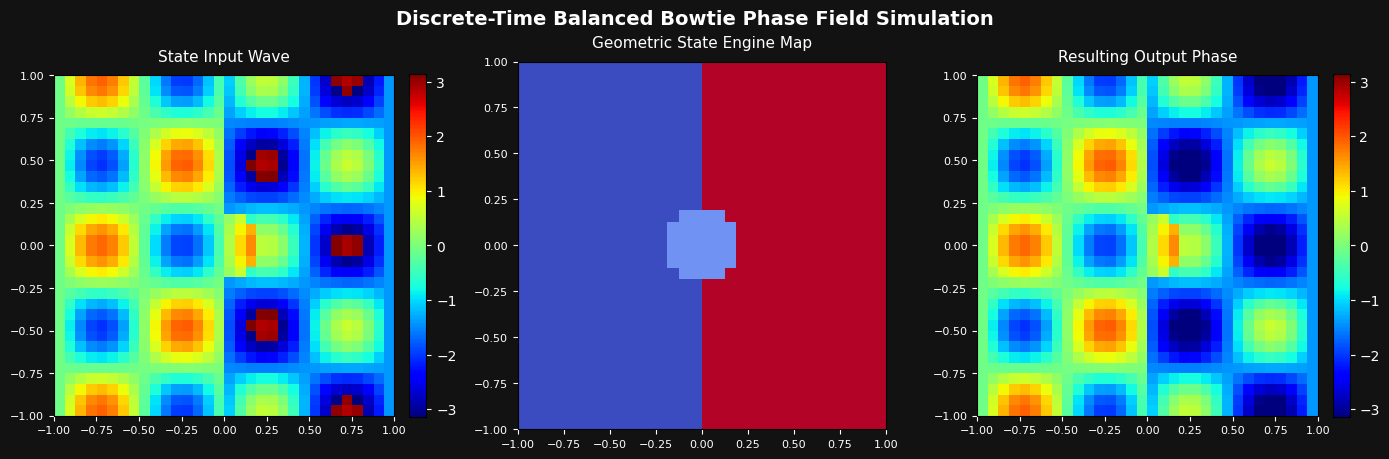

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 1. Grid & Engine Parameters ---
grid_size = 32
x = np.linspace(-1, 1, grid_size)
y = np.linspace(-1, 1, grid_size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

phi = (1 + np.sqrt(5)) / 2
drift_angle = np.radians(6.5)
golden_angle = np.radians(137.5)

# Define regional masks matching your geometry specs
node_mask = R < 0.2
contraction_mask = (X < 0) & (~node_mask)
expansion_mask = (X >= 0) & (~node_mask)

# Initialize the Phase Field (Panel 1)
# A complex wave field containing simulated baseline turbulence/vortices
field = np.exp(1j * (2 * np.sin(2 * np.pi * X) * np.cos(2 * np.pi * Y)))

# --- 2. Set Up the 3-Panel Visualizer Layout ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Discrete-Time Balanced Bowtie Phase Field Simulation", fontsize=14, color='white', weight='bold')
fig.patch.set_facecolor('#121212')

titles = ["State Input Wave", "Geometric State Engine Map", "Resulting Output Phase"]
im_plots = []

for i, ax in enumerate(axes):
    ax.set_facecolor('#121212')
    ax.tick_params(colors='white', labelsize=8)
    ax.set_title(titles[i], color='white', fontsize=11, pad=10)

# Initialize Panel 1 (Input Wave Phase)
im1 = axes[0].imshow(np.angle(field), cmap='jet', extent=[-1,1,-1,1], vmin=-np.pi, vmax=np.pi)
im_plots.append(im1)

# Initialize Panel 2 (Static Engine Domain Geometry)
engine_geometry = np.zeros((grid_size, grid_size))
engine_geometry[contraction_mask] = -1/3  # Contraction region marked negative
engine_geometry[node_mask] = 0            # Möbius Node center
engine_geometry[expansion_mask] = phi     # Expansion region marked positive
im2 = axes[1].imshow(engine_geometry, cmap='coolwarm', extent=[-1,1,-1,1])
im_plots.append(im2)

# Initialize Panel 3 (Resulting Output Phase Profile)
im3 = axes[2].imshow(np.angle(field), cmap='jet', extent=[-1,1,-1,1], vmin=-np.pi, vmax=np.pi)
im_plots.append(im3)

# Add matching colorbars to panels 1 and 3
for idx in [0, 2]:
    cbar = fig.colorbar(im_plots[idx], ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

plt.tight_layout()

# --- 3. Balanced Cellular Automaton Update Loop ---
def update(frame):
    global field

    # Extract current magnitude and angle profiles
    amplitude = np.abs(field)
    phase_angle = np.angle(field)

    # Prepare update matrices
    next_amplitude = np.copy(amplitude)
    next_phase = np.copy(phase_angle)

    # Apply State Engine Transformations to the field arrays concurrently
    # Panel 2 dictates how Panel 1 updates into Panel 3

    # Rule (b): Contraction zone updates (Shrink amplitude toward center)
    next_amplitude[contraction_mask] *= (1.0 / 3.0)

    # Rule (d): Expansion zone updates (Scale phase by Golden ratio rotation)
    next_phase[expansion_mask] += golden_angle
    next_amplitude[expansion_mask] *= 1.1 # Constrained numerical scale factor

    # Rule (e): Central Möbius Node Phase Inversion + Drift
    next_phase[node_mask] = -next_phase[node_mask] + drift_angle
    next_amplitude[node_mask] = 1.0  # Phase recombination reset

    # Reconstruct whole complex matrix field
    field = next_amplitude * np.exp(1j * next_phase)

    # Enforce global stabilization/normalization to prevent infinite explosion or dissipation
    field /= (np.max(np.abs(field)) + 1e-6)

    # Introduce small periodic atmospheric perturbation over time (continuous injection)
    field *= np.exp(1j * 0.05 * np.sin(frame * 0.1 + X))

    # Update live visualization viewports
    im_plots[0].set_array(np.angle(field))              # Changing dynamic input profile
    im_plots[2].set_array(np.unwrap(np.angle(field)))   # Unwrapped output profile visualization

    return im_plots

# Create moving visualization loop
ani = animation.FuncAnimation(fig, update, frames=200, interval=50, blit=True)
plt.show()

## Save the animation

To save the animation, we can use `ani.save()`. For MP4 files, `ffmpeg` is a commonly used backend. If you encounter issues, ensure `ffmpeg` is installed (it's usually pre-installed in Colab).

In [4]:
# To save the animation as an MP4 file
# This requires ffmpeg to be installed (often pre-installed in Colab)

# from matplotlib.animation import FFMpegWriter
# writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)

#ani.save('phase_field_simulation.mp4', writer=writer)

# Or, for a simpler save (will use default writer, often 'ffmpeg' if available)
ani.save('phase_field_simulation.mp4', fps=15, dpi=200)

In [5]:
# You can also save it as a GIF (requires ImageMagick, which is often not installed by default in Colab)
# ani.save('phase_field_simulation.gif', writer='imagemagick', fps=15, dpi=100)